In [1]:
import tensorflow as tf
import numpy as np
import keras
from keras import Input,Model
from keras.layers import Dense,Dropout,GlobalAveragePooling2D
from keras.losses import CategoricalCrossentropy
from keras.metrics import AUC
import matplotlib.pyplot as plt
import os
import glob
import torch
from torchvision.transforms import v2
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader
import math
from datetime import datetime
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# try:
#     import wandb
# except:
#     !pip install wandb
#     import wandb
# from wandb.integration.keras import WandbMetricsLogger

os.environ["KERAS_BACKEND"] = "tensorflow"
now = datetime.now()
date = now.strftime("%Y %m %d")

2026-03-23 14:21:30.621619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774275690.825902      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774275690.883593      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774275691.334785      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774275691.334830      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774275691.334833      55 computation_placer.cc:177] computation placer alr

In [2]:
# set seed for reproducibility
keras.utils.set_random_seed(42)
random.seed(42)
np.random.seed(42)

In [3]:
data_format = "channels_last"
keras.config.set_image_data_format(data_format)
print(f"Data channel format: {keras.config.image_data_format()}")

Data channel format: channels_last


In [4]:
# strategy = tf.distribute.MirroredStrategy()
# print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

In [5]:
class C:
    raw_path = "/kaggle/input/gsoc-2024"
    train_data = os.path.join(raw_path,"dataset/train")
    val_data = os.path.join(raw_path,"dataset/val")
    weights = f"weights_{date}.weights.h5"
    num_classes = 3
    epochs = 50
    batch_size = 128
    height = 150
    shape = [height,height]
    base_lr = 1e-4
    # autotune = tf.data.experimental.AUTOTUNE
    # buffer = 1024
    

In [6]:
# wandb setup
# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("my_dash")
# !wandb login $secret_value_0

# wandb.init(
#     project="GSOC25_DeepLense_Test",
#     config={
#         "learning_rate": C.base_lr,
#         "batch_size": C.batch_size,
#         "augmentation scheme": "center_crop, affine transformation and perspective transformation",
#         "model": "Resnet50"
#     },
#     group = "Test 1",
#     job_type = "supervised"
# )

In [7]:
def npy_loader(path):
    sample = np.load(path)
    tensor = torch.from_numpy(sample).float()
    return tensor

def target_transform(label):
    return torch.eye(3)[label]

In [8]:
print("number of images in train 'no': {}".format(len(glob.glob(os.path.join(C.train_data,"no/*")))))
print("number of images in train 'sphere': {}".format(len(glob.glob(os.path.join(C.train_data,"sphere/*")))))
print("number of images in train 'vort': {}".format(len(glob.glob(os.path.join(C.train_data,"vort/*")))))

number of images in train 'no': 10000
number of images in train 'sphere': 10000
number of images in train 'vort': 10000


In [9]:
print("number of images in validation 'no': {}".format(len(glob.glob(os.path.join(C.val_data,"no/*")))))
print("number of images in validation 'sphere': {}".format(len(glob.glob(os.path.join(C.val_data,"sphere/*")))))
print("number of images in validation 'vort': {}".format(len(glob.glob(os.path.join(C.val_data,"vort/*")))))

number of images in validation 'no': 2500
number of images in validation 'sphere': 2500
number of images in validation 'vort': 2500


In [10]:
class RepeatChannels(object):
    def __init__(self, num_channels=3):
        self.num_channels = num_channels
        
    def __call__(self, x):
        # If x is a tensor with shape [H, W] or [1, H, W]
        x = (x * 2) - 1
        if len(x.shape) == 2:  # [H, W]
            x = x.unsqueeze(0)  # Add channel dimension -> [1, H, W]
        
        if x.shape[0] == 1:  # If single channel [1, H, W]
            x = x.repeat(self.num_channels, 1, 1)  # Repeat to [3, H, W]
            x = x.permute(1, 2, 0)
        
        return x

In [11]:
train_dataset = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        v2.RandomHorizontalFlip(p = 0.5),
        v2.RandomApply(
            transforms = [
                v2.RandomAffine(
            degrees=(0,90),
            translate=(0.1,0.3),
            # scale=(0.3, 0.5),
        )
            ],
            p = 0.2
        ),
        v2.RandomPerspective(
            distortion_scale=0.3,
            p=0.3
        ),
        RepeatChannels(3)
    ]),
    target_transform=target_transform
)

val_dataset = DatasetFolder(
    root=C.val_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        RepeatChannels(3),
    ]),
    target_transform=target_transform
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=C.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=C.batch_size, shuffle=False, num_workers=0)

In [13]:
def visualize_batch(dataloader, num_batches=1, class_names=None):
    if class_names is None:
        class_names = list(dataloader.dataset.class_to_idx.keys())
    
    # Get a batch of images
    for batch_idx, (images, labels) in enumerate(dataloader):
        if batch_idx >= num_batches:
            break
            
        # Convert tensors to numpy for plotting
        images = images.numpy()
        
        # Create a grid of subplots
        fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12))
        axes = axes.flatten()
        
        # Plot each image in the batch
        for i in range(min(16, len(images))):
            img = (images[i] + 1) / 2 # convert back to [0, 1] for visualization 
            label = torch.argmax(labels[i], axis=0).item()
            
            # Determine how to display the image based on its shape
            if len(img.shape) == 3:  # Color image (C, H, W)
                if img.shape[2] == 1:  # Single channel
                    axes[i].imshow(img)
                else:  # Multiple channels (e.g., RGB)
                    # Move channels to the end for matplotlib (H, W, C)
                    # img_display = np.transpose(img, (1, 2, 0))
                    img_display = img
                    # If more than 3 channels, just use first 3
                    if img_display.shape[2] > 3:
                        img_display = img_display[:, :, :3]
                    axes[i].imshow(img_display)
            elif len(img.shape) == 2:  # Grayscale image (H, W)
                axes[i].imshow(img, cmap='gray')
            else:  # Handle other shapes appropriately
                axes[i].text(0.5, 0.5, f"Shape: {img.shape}", 
                             ha='center', va='center', transform=axes[i].transAxes)
            
            # Add class label
            axes[i].set_title(f"Class: {class_names[label]}")
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.suptitle(f"Batch {batch_idx+1}")
        plt.show()

In [14]:
dummy_dataset = DatasetFolder(
    root=C.train_data,
    loader=npy_loader,
    extensions=('.npy',),
    transform=v2.Compose([
        v2.ToImage(),
        v2.RandomHorizontalFlip(p = 0.5),
        v2.RandomApply(
            transforms = [
                v2.RandomAffine(
            degrees=(0,90),
            translate=(0.1,0.3),
            # scale=(0.3, 0.5),
        )
            ],
            p = 0.3
        ),
        v2.RandomPerspective(
            distortion_scale=0.3,
            p=0.3
        ),
        RepeatChannels(3)
    ]),
    target_transform=target_transform
)
dummy_loader = DataLoader(dummy_dataset, batch_size=16, shuffle=True, num_workers=0)

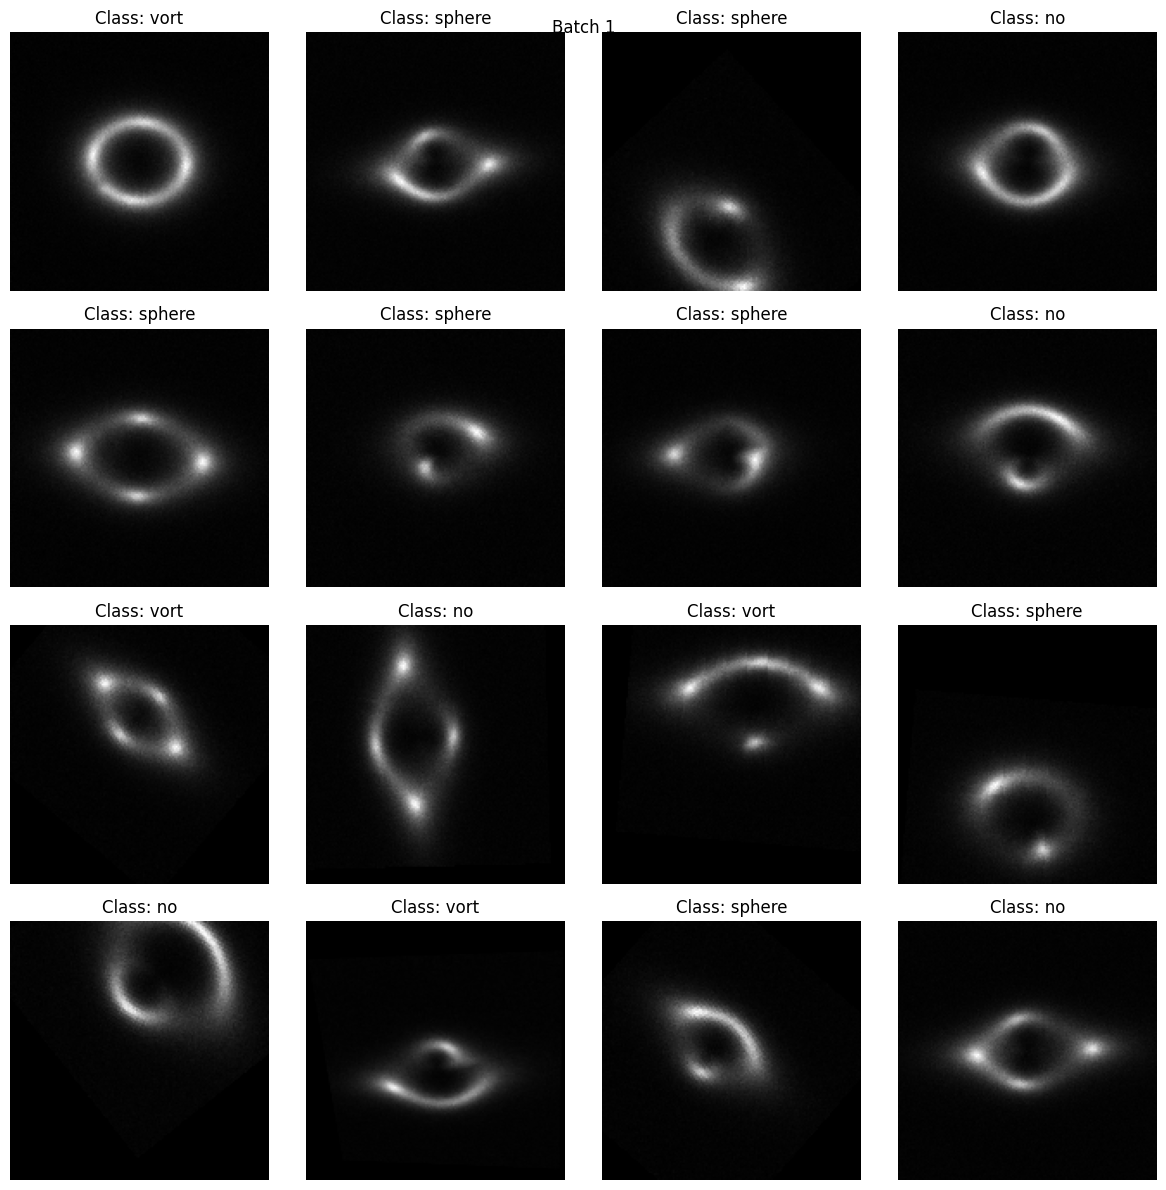

In [15]:
visualize_batch(dummy_loader, num_batches=1, class_names=['no', 'sphere', 'vort'])

In [16]:
# steps_per_epoch = int(np.ceil(30000 / C.batch_size))
# validation_steps = int(np.ceil(7500 / C.batch_size))

In [17]:
def get_model():
    inp = Input(shape=[*C.shape, 3])
    base = keras.applications.EfficientNetV2B2(
      weights = "imagenet",
      include_top = False,
        include_preprocessing = False,
      input_shape = [*C.shape, 3]
    )
    base.trainable = True
    # x = keras.applications.ResNet50V2(inp)
    # x = keras.layers.Conv2D(
    #     filters=3,
    #     kernel_size=1,    
    #     padding='same',
    #     use_bias=False,
    #     name='channel_expand'
    # )(inp)
    x = base(inp,training=False)
    x = GlobalAveragePooling2D()(x)
    out = Dense(C.num_classes,activation="softmax")(x)
    model = Model(inputs=inp,outputs=out)
    return model

In [18]:
# with strategy.scope():
deeplense_model = get_model()
deeplense_model.summary()

I0000 00:00:1774275797.805695      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)  │ (None, 5, 5, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         4,227 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,773,601 (33.47 MB)

 Trainable params: 8,691,313 (33.15 MB)

 Non-trainable params: 82,288 (321.44 KB)

In [19]:
lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = C.base_lr,
    decay_steps = C.epochs * len(train_loader),
    warmup_target = C.base_lr * 10,
    warmup_steps = (C.epochs * len(train_loader)) // 5
)

deeplense_model.compile(
      loss = CategoricalCrossentropy,
      optimizer = keras.optimizers.Adam(
          learning_rate = lr_scheduler,
    #           weight_decay = C.decay
      ),
      metrics = [AUC(name="auc")],
    )

es = keras.callbacks.EarlyStopping(
    monitor = "val_auc",
    patience = 3,
    restore_best_weights = True,
    verbose = 1,
    min_delta = 1e-4
)
hist = deeplense_model.fit(
    train_loader,
    # steps_per_epoch = steps_per_epoch,
    validation_data = val_loader,
    # validation_steps = validation_steps, 
    epochs = C.epochs,
    callbacks = [es]#, WandbMetricsLogger()],
)

# wandb.finish()

Epoch 1/50


I0000 00:00:1774275854.847438     131 service.cc:152] XLA service 0x7856a0004770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774275854.847507     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774275863.408934     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-23 14:24:38.592398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:24:38.780042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:24:39.261926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - auc: 0.5325 - loss: 1.1093

2026-03-23 14:29:21.168954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:29:21.350764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:29:21.729344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:29:21.916434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 14:29:22.404057: E external/local_xla/xla/stream_

235/235 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - auc: 0.5328 - loss: 1.1092 - val_auc: 0.6680 - val_loss: 1.0113
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 329ms/step - auc: 0.6806 - loss: 0.9920 - val_auc: 0.8249 - val_loss: 0.7786
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 327ms/step - auc: 0.8394 - loss: 0.7482 - val_auc: 0.8840 - val_loss: 0.6457
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 354ms/step - auc: 0.9208 - loss: 0.5396 - val_auc: 0.9586 - val_loss: 0.3951
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 76s 323ms/step - auc: 0.9475 - loss: 0.4420 - val_auc: 0.9702 - val_loss: 0.3372
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 445ms/step - auc: 0.9612 - loss: 0.3800 - val_auc: 0.9785 - val_loss: 0.2855
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 88s 374ms/step - auc: 0.9694 - loss: 0.3369 - val_auc: 0.9766 - val_loss: 0.3055
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 78s 331ms/step - auc: 0.9733 - loss: 0.3151 - val_auc: 0.9826 - val_loss: 0.2562
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 78s 

In [20]:
deeplense_model.evaluate(val_loader)

59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - auc: 0.9936 - loss: 0.1570


[0.1621328592300415, 0.9921822547912598]

In [21]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

train_auc = hist.history["auc"]
val_auc = hist.history["val_auc"]

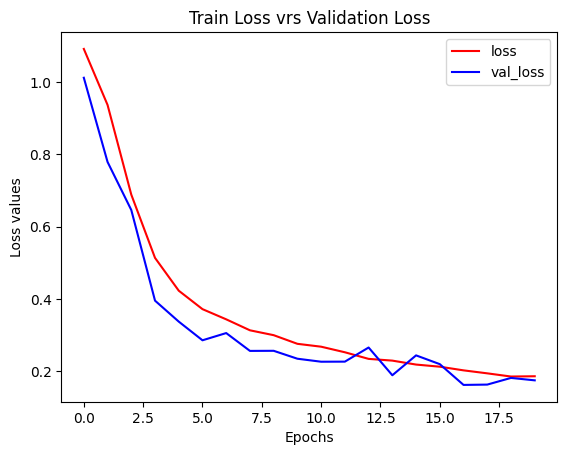

In [22]:
plt.plot(loss, color="r", label = "loss")
plt.plot(val_loss, color="b", label = "val_loss")
plt.title("Train Loss vrs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss values")
plt.legend()

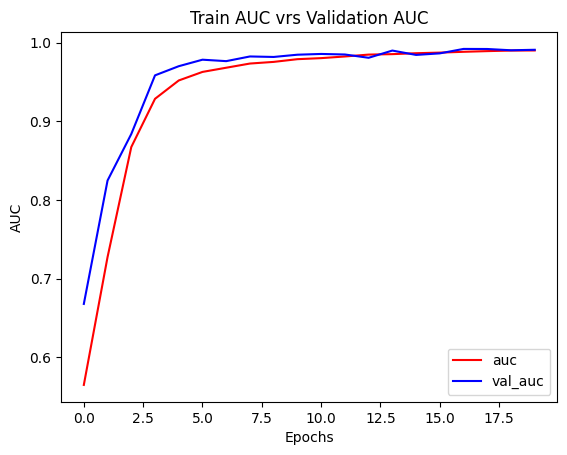

In [23]:
plt.plot(train_auc, color="r", label = "auc")
plt.plot(val_auc, color="b", label = "val_auc")
plt.title("Train AUC vrs Validation AUC")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()

In [24]:
y_probs = deeplense_model.predict(val_loader)
y_preds = np.argmax(y_probs, axis=1)
# y_preds = np.argmax(deeplense_model.predict(val_loader), axis=1)

59/59 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step


In [25]:
report = classification_report(
    val_loader.dataset.targets, 
    y_preds,
    target_names = list(val_dataset.class_to_idx.keys())
)
print(report)

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      2500
      sphere       0.96      0.90      0.93      2500
        vort       0.95      0.96      0.95      2500

    accuracy                           0.94      7500
   macro avg       0.94      0.94      0.94      7500
weighted avg       0.94      0.94      0.94      7500



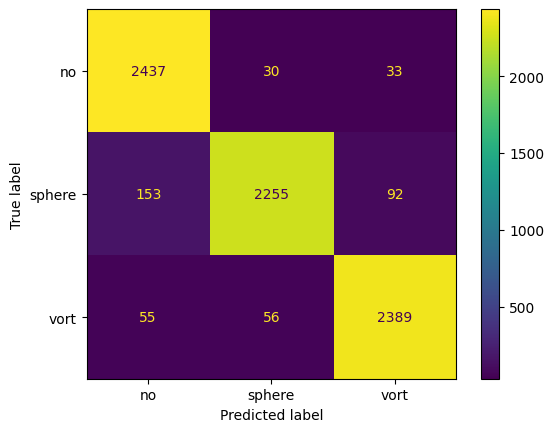

In [26]:
cm = confusion_matrix(
    val_loader.dataset.targets, 
    y_preds,
    labels = list(val_dataset.class_to_idx.values())
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(val_dataset.class_to_idx.keys())
                             )
disp.plot()

In [27]:
def draw_roc_curve(labels, probs, class_names):
    colors = ['steelblue', 'tomato', 'seagreen']
    plt.figure(figsize=(7, 6))
    for i in range(3):
        fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        print(f"Class '{class_names[i]}' -> TPR={tpr[best_idx]:.3f}\tFPR={fpr[best_idx]:.3f}")
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f"Class {class_names[i]} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curve (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


In [28]:
y_true_binarized = label_binarize(val_loader.dataset.targets, 
                                  classes=list(val_loader.dataset.class_to_idx.values())
                                 )

Class 'no' -> TPR=0.992	FPR=0.054
Class 'sphere' -> TPR=0.916	FPR=0.028
Class 'vort' -> TPR=0.966	FPR=0.034


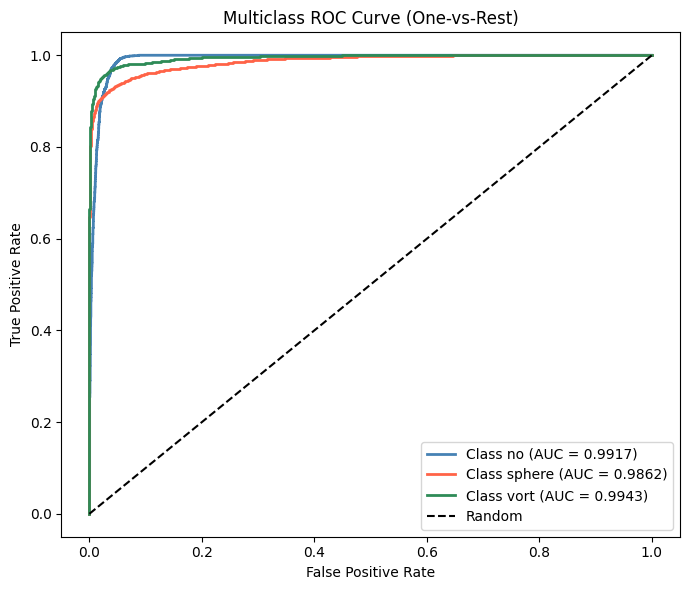

In [29]:
draw_roc_curve(y_true_binarized, y_probs, class_names=['no', 'sphere', 'vort'])

In [31]:
deeplense_model.save_weights(C.weights)